# Omission Error Rate

> Measure and visualize the rate of omission errors by study position.

An omission error occurs when a participant fails to recall an item that was presented on the study list. The omission error rate curve plots the proportion of omissions at each study position, revealing which serial positions are most vulnerable to being forgotten entirely.

This notebook is parameterized for use with [papermill](https://papermill.readthedocs.io/).

| Parameter | Description |
|-----------|-------------|
| `run_tag` | Label for this analysis run |
| `data_path` | Path to HDF5 dataset file |
| `figure_dir` | Directory for saving figures |
| `figure_str` | Filename for saved figure (empty string to skip saving) |
| `ylim` | Y-axis limits as tuple, or `None` for auto |
| `size` | Maximum study positions per item |
| `trial_query` | Query string for trial selection |

: Notebook parameters {#tbl-parameters}

In [1]:
#| include: false
from nbdev.showdoc import show_doc

In [2]:
#| code-summary: Imports and setup
import os
import warnings

import jax.numpy as jnp
import matplotlib.pyplot as plt

from jaxcmr.analyses.omission_error_rate import (
    trial_omission_error_rate,
    omission_error_rate,
    plot_omission_error_rate,
)
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data

warnings.filterwarnings("ignore")


def save_figure(figure_dir, figure_str, suffix=None):
    plt.tight_layout()
    if not figure_str:
        plt.show()
        return
    os.makedirs(figure_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    figure_path = os.path.join(figure_dir, f"{figure_str}{suffix_str}.png")
    plt.savefig(figure_path, bbox_inches="tight", dpi=600)
    plt.show()

In [3]:
#| code-summary: Parameters for this analysis

run_tag = "Omission Error Rate"
data_path = "data/Gordon2021.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
size = 3
trial_query = "jnp.logical_and(data['condition'] == 2, data['listLength'] == 7)"

In [4]:
#| code-summary: Load data and generate trial mask
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)

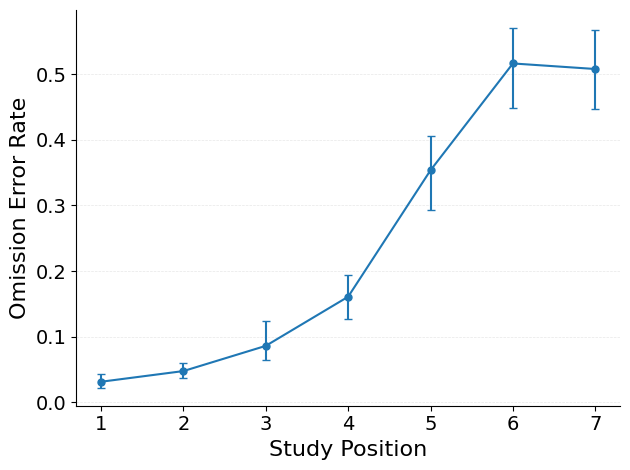

In [5]:
#| code-summary: Plot omission error rate
#| label: fig-omission-error-rate
#| fig-cap: "Omission error rate by study position."
plot_omission_error_rate(datasets=data, trial_masks=trial_mask, size=size)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str)

---

## Reference

In [6]:
#| echo: false
show_doc(plot_omission_error_rate)

---

### plot_omission_error_rate

>      plot_omission_error_rate (datasets:Union[Sequence[jaxcmr.typing.RecallDat
>                                aset],jaxcmr.typing.RecallDataset], trial_masks
>                                :Union[Sequence[jaxtyping.Bool[Array,'trial_cou
>                                nt']],jaxtyping.Bool[Array,'trial_count']],
>                                color_cycle:Optional[list[str]]=None,
>                                labels:Optional[Sequence[str]]=None,
>                                contrast_name:Optional[str]=None,
>                                axis:Optional[matplotlib.axes._axes.Axes]=None,
>                                size:int=3, confidence_level:float=0.95)

*Plot omission error rate curves with confidence intervals.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| datasets | Union |  | One or more datasets to plot. |
| trial_masks | Union |  | Boolean mask(s) selecting trials. |
| color_cycle | Optional | None | Colors for each curve. |
| labels | Optional | None | Legend labels for each curve. |
| contrast_name | Optional | None | Legend title. |
| axis | Optional | None | Existing Axes to plot on. |
| size | int | 3 | Max study positions an item can occupy. |
| confidence_level | float | 0.95 | Confidence level for error bounds. |
| **Returns** | **Axes** |  | **Matplotlib Axes with omission error rate curves.** |

In [7]:
#| echo: false
show_doc(omission_error_rate)

---

### omission_error_rate

>      omission_error_rate (dataset:jaxcmr.typing.RecallDataset, size:int=3)

*Return position-specific omission error rate.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| dataset | RecallDataset |  | Recall dataset with ``recalls`` and ``pres_itemnos``. |
| size | int | 3 | Max study positions an item can occupy. |
| **Returns** | **Float[Array, 'study_positions']** |  | **Mean omission rate at each study position.** |

In [8]:
# Items 1-3 studied; only item 1 recalled -> positions 2 and 3 are omissions
recalls = jnp.array([1, 0, 0], dtype=jnp.int32)
presentations = jnp.array([1, 2, 3], dtype=jnp.int32)

result = trial_omission_error_rate(recalls, presentations, size=1)
assert jnp.array_equal(result, jnp.array([False, True, True]))

In [9]:
#| echo: false
show_doc(trial_omission_error_rate)

---

### trial_omission_error_rate

>      trial_omission_error_rate
>                                 (recalls:jaxtyping.Integer[Array,'recall_posit
>                                 ions'], presentations:jaxtyping.Integer[Array,
>                                 'study_positions'], size:int=3)

*Flag omission errors at each study position for one trial.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| recalls | Integer[Array, 'recall_positions'] |  | Recall sequence for a trial. 1-indexed; 0 pads. |
| presentations | Integer[Array, 'study_positions'] |  | Presented item IDs for the trial. 1-indexed; 0 pads. |
| size | int | 3 | Max study positions an item can occupy. |
| **Returns** | **Bool[Array, 'study_positions']** |  | **True where the study position was never recalled.** |

In [10]:
# All items recalled -> no omissions
result = trial_omission_error_rate(
    jnp.array([1, 2, 3], dtype=jnp.int32),
    jnp.array([1, 2, 3], dtype=jnp.int32),
    size=1,
)
assert jnp.array_equal(result, jnp.array([False, False, False]))